In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input/brain-tumor-mri-dataset"):
    for d in dirs:
        print(os.path.join(root, d))


/kaggle/input/brain-tumor-mri-dataset/Training
/kaggle/input/brain-tumor-mri-dataset/Testing
/kaggle/input/brain-tumor-mri-dataset/Training/pituitary
/kaggle/input/brain-tumor-mri-dataset/Training/notumor
/kaggle/input/brain-tumor-mri-dataset/Training/meningioma
/kaggle/input/brain-tumor-mri-dataset/Training/glioma
/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary
/kaggle/input/brain-tumor-mri-dataset/Testing/notumor
/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma
/kaggle/input/brain-tumor-mri-dataset/Testing/glioma


In [ ]:
import os

# Define the base directories
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/brain-tumor-mri-dataset/Testing"

def count_images_in_subfolders(base_dir):
    print(f"\n📁 Image counts in: {base_dir}\n")
    total = 0
    for folder in sorted(os.listdir(base_dir)):
        folder_path = os.path.join(base_dir, folder)
        if os.path.isdir(folder_path):
            count = len([
                f for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            print(f"{folder:20s} : {count} images")
            total += count
    print(f"➡️ Total images in {os.path.basename(base_dir)}: {total}\n")
    return total

# Count images in both folders
train_total = count_images_in_subfolders(train_dir)
test_total  = count_images_in_subfolders(test_dir)

print(f"✅ Grand Total (Training + Testing): {train_total + test_total} images")



📁 Image counts in: /kaggle/input/brain-tumor-mri-dataset/Training

glioma               : 1321 images
meningioma           : 1339 images
notumor              : 1595 images
pituitary            : 1457 images
➡️ Total images in Training: 5712


📁 Image counts in: /kaggle/input/brain-tumor-mri-dataset/Testing

glioma               : 300 images
meningioma           : 306 images
notumor              : 405 images
pituitary            : 300 images
➡️ Total images in Testing: 1311

✅ Grand Total (Training + Testing): 7023 images


In [ ]:
import os
import shutil

# Source directories
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir  = "/kaggle/input/brain-tumor-mri-dataset/Testing"


merged_dir = "/kaggle/working/Brain_Tumor_Merged"

# Create destination folder if it doesn’t exist
os.makedirs(merged_dir, exist_ok=True)

# Merge images from both directories
for src_dir in [train_dir, test_dir]:
    for folder in os.listdir(src_dir):
        src_folder = os.path.join(src_dir, folder)
        if os.path.isdir(src_folder):
            dest_folder = os.path.join(merged_dir, folder)
            os.makedirs(dest_folder, exist_ok=True)
            for file in os.listdir(src_folder):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_path = os.path.join(src_folder, file)
                    dest_path = os.path.join(dest_folder, file)

                    # Avoid overwriting files with same name
                    if os.path.exists(dest_path):
                        base, ext = os.path.splitext(file)
                        i = 1
                        while os.path.exists(dest_path):
                            dest_path = os.path.join(dest_folder, f"{base}_{i}{ext}")
                            i += 1
                    shutil.copy2(src_path, dest_path)

print("✅ Merge completed! All images copied to:", merged_dir)


print("\n📊 Checking merged folder image counts:\n")
total = 0
for folder in os.listdir(merged_dir):
    folder_path = os.path.join(merged_dir, folder)
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"{folder:20s} : {count} images")
        total += count
print(f"\n➡️ Total images in merged folder: {total}")


✅ Merge completed! All images copied to: /kaggle/working/Brain_Tumor_Merged

📊 Checking merged folder image counts:

pituitary            : 1757 images
notumor              : 2000 images
glioma               : 1621 images
meningioma           : 1645 images

➡️ Total images in merged folder: 7023



Processing class: glioma (1621 images)


glioma Progress: 100%|█████████████████████████████████████████| 1621/1621 [00:10<00:00, 152.31it/s]



Processing class: meningioma (1645 images)


meningioma Progress: 100%|█████████████████████████████████████| 1645/1645 [00:09<00:00, 168.91it/s]



Processing class: notumor (2000 images)


notumor Progress: 100%|████████████████████████████████████████| 2000/2000 [00:10<00:00, 187.80it/s]



Processing class: pituitary (1757 images)


pituitary Progress: 100%|██████████████████████████████████████| 1757/1757 [00:10<00:00, 164.88it/s]


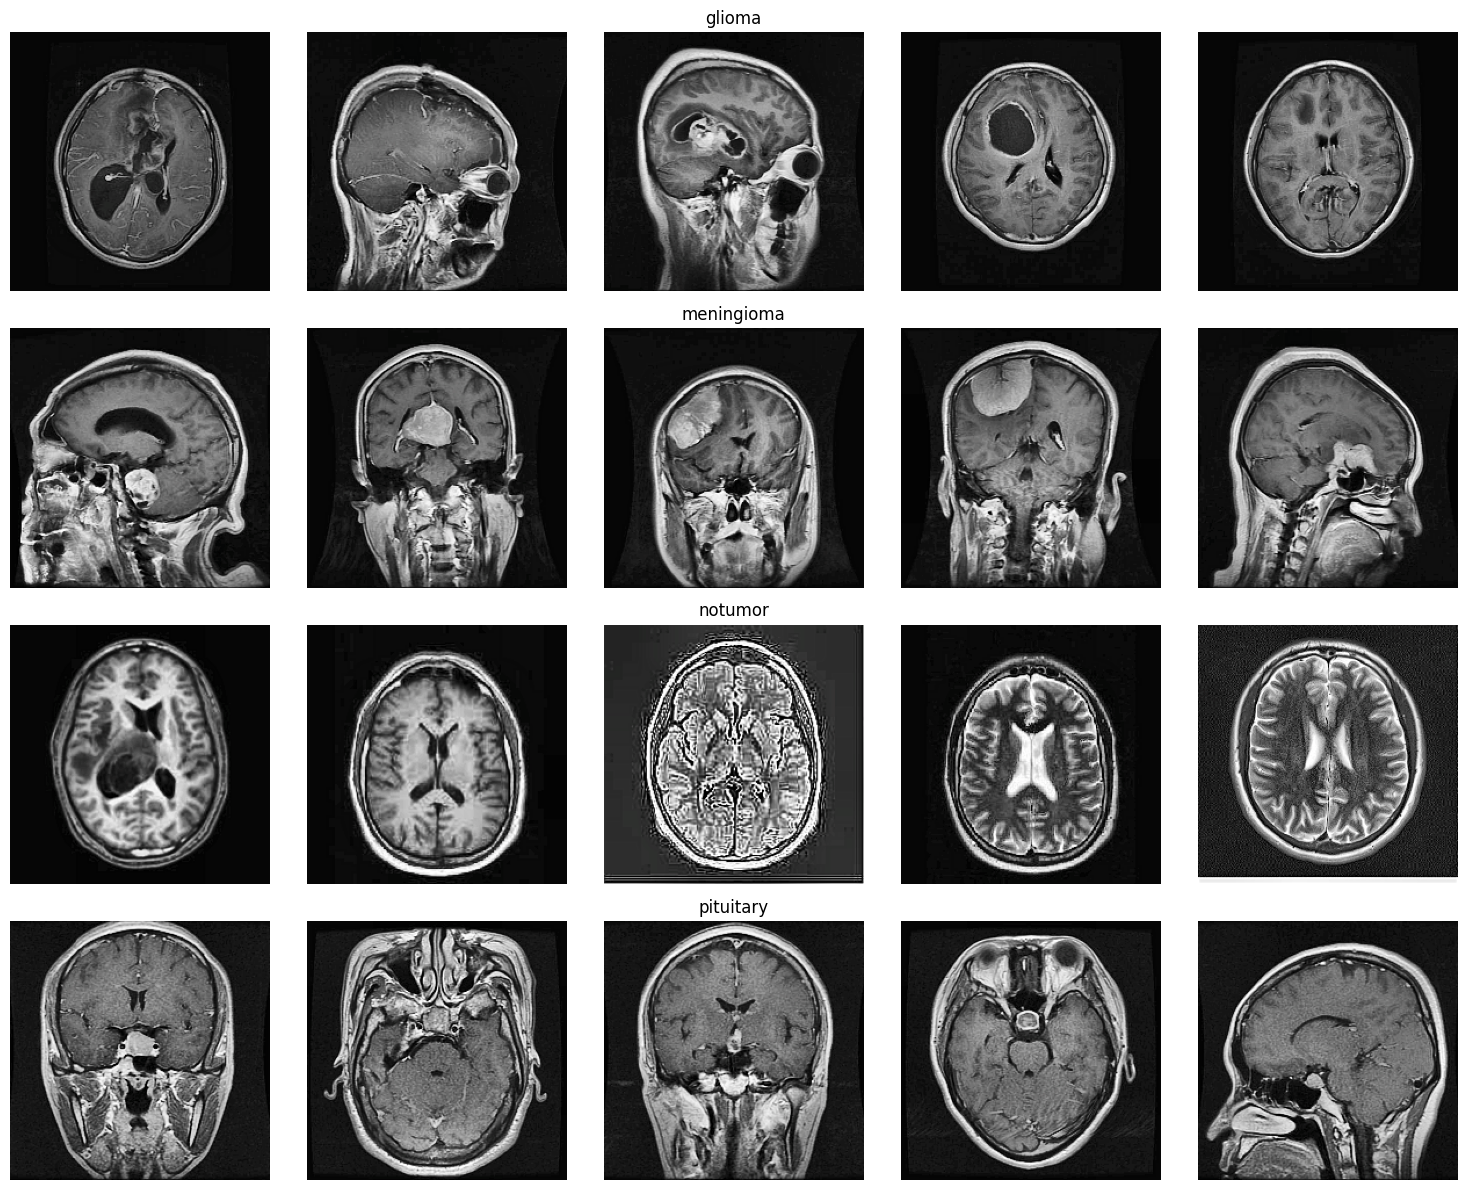


✅ Preprocessed images saved in: /kaggle/working/preprocessed_dataset


In [ ]:
import os
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

# Paths
input_dir = "/kaggle/working/Brain_Tumor_Merged"
output_dir = "/kaggle/working/preprocessed_dataset"
os.makedirs(output_dir, exist_ok=True)

img_size = (224, 224)
num_samples = 5
device = "cuda" if torch.cuda.is_available() else "cpu"

# Gaussian filter (GPU)
def gaussian_filter_gpu(img_tensor, kernel_size=5, sigma=1.0):
    C,H,W = img_tensor.shape
    x = torch.arange(kernel_size, dtype=torch.float32, device=img_tensor.device) - kernel_size//2
    gauss = torch.exp(-(x**2)/(2*sigma**2))
    gauss = gauss / gauss.sum()
    gauss_2d = gauss[:, None] @ gauss[None, :]
    gauss_2d = gauss_2d.expand(C,1,kernel_size,kernel_size)
    img_tensor = img_tensor.unsqueeze(0)
    img_filtered = F.conv2d(img_tensor, gauss_2d, padding=kernel_size//2, groups=C)
    return img_filtered[0]

# Classes
classes = sorted([d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))])

fig, axes = plt.subplots(len(classes), num_samples, figsize=(15,3*len(classes)))

for i, cls in enumerate(classes):
    cls_path = os.path.join(input_dir, cls)
    save_cls_path = os.path.join(output_dir, cls)
    os.makedirs(save_cls_path, exist_ok=True)

    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".png",".jpeg"))]
    sample_files = random.sample(files, min(num_samples,len(files)))

    print(f"\nProcessing class: {cls} ({len(files)} images)")
    for file in tqdm(files, desc=f"{cls} Progress", ncols=100):
        img_path = os.path.join(cls_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # 1️⃣ Resize
        img_resized = cv2.resize(img, img_size)

        # 2️⃣ CLAHE on L channel
        lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
        l,a,b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe,a,b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

        # 3️⃣ Convert to tensor [C,H,W] in 0-1
        img_tensor = torch.from_numpy(img_clahe.transpose(2,0,1)).float().to(device)/255.0

        # 4️⃣ Gaussian smoothing
        img_blur = gaussian_filter_gpu(img_tensor, kernel_size=5, sigma=1.0)

        # 5️⃣ Sharpening (Unsharp mask)
        img_sharp = torch.clamp(1.5*img_tensor - 0.5*img_blur,0,1)

        # 6️⃣ Contrast Stretching
        min_val = img_sharp.min()
        max_val = img_sharp.max()
        img_contrast = (img_sharp - min_val)/(max_val - min_val + 1e-8)

        # 7️⃣ Save image back to CPU
        img_final = (img_contrast.cpu().numpy()*255).astype(np.uint8).transpose(1,2,0)
        cv2.imwrite(os.path.join(save_cls_path, file), img_final)

        # Plot sample images
        if file in sample_files:
            ax = axes[i,sample_files.index(file)]
            ax.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
            ax.axis("off")
            if sample_files.index(file) == num_samples//2:
                ax.set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()
print("\n✅ Preprocessed images saved in:", output_dir)


In [ ]:
import os
import shutil
import random

# Preprocessed dataset path
preprocessed_dir = "/kaggle/working/preprocessed_dataset"

# Split paths
split_base = "/kaggle/working/brain_split"
train_dir = os.path.join(split_base, "train")
val_dir   = os.path.join(split_base, "val")
test_dir  = os.path.join(split_base, "test")


for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Split ratios
train_ratio = 0.80
val_ratio = 0.10
test_ratio = 0.10

classes = sorted(os.listdir(preprocessed_dir))

for cls in classes:
    cls_path = os.path.join(preprocessed_dir, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(files)

    n_total = len(files)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)
    n_test = n_total - n_train - n_val

    splits = {
        train_dir: files[:n_train],
        val_dir: files[n_train:n_train+n_val],
        test_dir: files[n_train+n_val:]
    }

    for split_folder, split_files in splits.items():
        cls_split_path = os.path.join(split_folder, cls)
        os.makedirs(cls_split_path, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(cls_split_path, f))

print("✅ Dataset split into 80-10-10 and saved in:", split_base)


✅ Dataset split into 80-10-10 and saved in: /kaggle/working/brain_split


In [ ]:
import os

split_base = "/kaggle/working/brain_split"
splits = ["train", "val", "test"]

for split in splits:
    split_path = os.path.join(split_base, split)
    print(f"\n📂 {split.capitalize()} Split:")
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        print(f"{cls}: {num_images} images")



📂 Train Split:
glioma: 1296 images
meningioma: 1316 images
notumor: 1600 images
pituitary: 1405 images

📂 Val Split:
glioma: 162 images
meningioma: 164 images
notumor: 200 images
pituitary: 175 images

📂 Test Split:
glioma: 163 images
meningioma: 165 images
notumor: 200 images
pituitary: 177 images


In [ ]:
!pip install GPUtil


  Preparing metadata (setup.py) ... done
  Created wheel for GPUtil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=96c20977e8093300a72f81cbb60f629686c4f095fd57f2f441622eceb9612d66
  Stored in directory: /root/.cache/pip/wheels/2b/4d/8f/55fb4f7b9b591891e8d3f72977c4ec6c7763b39c19f0861595
Successfully built GPUtil


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


100%|██████████| 8.79M/8.79M [00:00<00:00, 138MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 1.1423 | Val Loss: 0.6777 | Train Acc: 0.7800 | Val Acc: 0.8659
Epoch [2/50] | Train Loss: 0.4511 | Val Loss: 0.2867 | Train Acc: 0.9065 | Val Acc: 0.9201
Epoch [3/50] | Train Loss: 0.2087 | Val Loss: 0.1593 | Train Acc: 0.9518 | Val Acc: 0.9629
Epoch [4/50] | Train Loss: 0.1103 | Val Loss: 0.1243 | Train Acc: 0.9760 | Val Acc: 0.9700
Epoch [5/50] | Train Loss: 0.0709 | Val Loss: 0.1050 | Train Acc: 0.9856 | Val Acc: 0.9686
Epoch [6/50] | Train Loss: 0.0451 | Val Loss: 0.1112 | Train Acc: 0.9915 | Val Acc: 0.9658
Epoch [7/50] | Train Loss: 0.0375 | Val Loss: 0.0855 | Train Acc: 0.9936 | Val Acc: 0.9757
Epoch [8/50] | Train Loss: 0.0222 | Val Loss: 0.0997 | Train Acc: 0.9966 | Val Acc: 0.9672
Epoch [9/50] | Train Loss: 0.0252 | Val Loss: 0.0841 | Train Acc: 0.9945 | Val Acc: 0.9800
Epoch [10/50] | Train Loss: 0.0217 | Val Loss: 0.0805 | Train Acc: 0.9963 | Val Acc: 0.9743
Epoch [11/50] | Train Loss: 0.0141 | Val Loss: 0.0696 | Train Acc: 0.9980 | Val Acc: 0.97

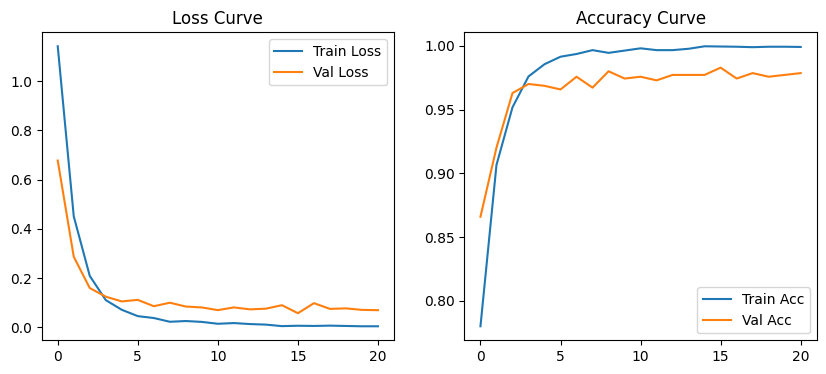


Training completed in 354.17 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9992    1.0000    0.9996      1296
  meningioma     1.0000    1.0000    1.0000      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     1.0000    0.9993    0.9996      1405

    accuracy                         0.9998      5617
   macro avg     0.9998    0.9998    0.9998      5617
weighted avg     0.9998    0.9998    0.9998      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9874    0.9691    0.9782       162
  meningioma     0.9634    0.9634    0.9634       164
     notumor     0.9901    1.0000    0.9950       200
   pituitary     0.9886    0.9943    0.9915       175

    accuracy                         0.9829       701
   macro avg     0.9824    0.9817    0.9820       701
weighted avg     0.9829    0.9829    0.9828       701


=== Test Cl

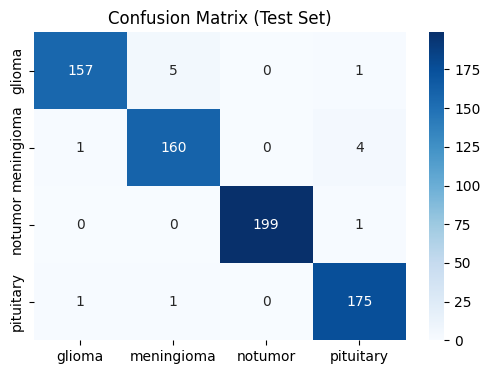


Cohen’s Kappa: 0.9735
Mean PPV: 0.9795
Mean NPV: 0.9935
Mean Sensitivity: 0.9791
Mean Specificity: 0.9935


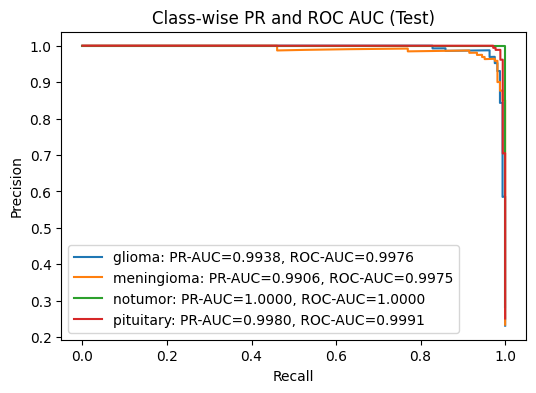


Accuracy: 0.9801
95% Confidence Interval: (0.9688, 0.9901)

GPU Memory Used: 40.57 MB
RAM Used: 2.28 GB
Inference Time: 1.31 seconds
Training Time: 354.17 seconds

Permutation Test p-value (accuracy vs random): 0.0000


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - ShuffleNetV2 + SE
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    roc_auc_score, precision_recall_curve, auc
)
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Squeeze-and-Excitation (SE) Block
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.fc(x)
        return x * scale

# ============================================================
# 3️⃣ ShuffleNetV2 + SE Head
# ============================================================

class ShuffleNetV2_SE(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.shufflenet_v2_x1_0(weights='IMAGENET1K_V1')
        self.features = nn.Sequential(*(list(base_model.children())[:-1]))
        self.se = SEBlock(channels=1024)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.se(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = ShuffleNetV2_SE(num_classes=num_classes).to(device)

# ============================================================
# 4️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 5️⃣ Training Loop
# ============================================================

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "shuffle_se_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 6️⃣ Simple Evaluation Function
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ============================================================
# 7️⃣ Test Evaluation
# ============================================================

def evaluate_test(model, loader, training_time):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))

    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

    # ===================== Permutation Test =====================
    n_permutations = 100
    perm_accs = []
    y_true_arr = np.array(y_true)
    for _ in range(n_permutations):
        perm_labels = np.random.permutation(y_true_arr)
        perm_accs.append(np.mean(perm_labels == y_pred))
    perm_accs = np.array(perm_accs)
    p_value = np.mean(perm_accs >= acc)
    print(f"\nPermutation Test p-value (accuracy vs random): {p_value:.4f}")

# ============================================================
# 8️⃣ Train + Evaluate
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("shuffle_se_model.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")
evaluate_test(model, test_loader, training_time)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


100%|██████████| 4.73M/4.73M [00:00<00:00, 111MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.5703 | Val Loss: 0.2978 | Train Acc: 0.7727 | Val Acc: 0.8745
Epoch [2/50] | Train Loss: 0.2869 | Val Loss: 0.2413 | Train Acc: 0.9001 | Val Acc: 0.9130
Epoch [3/50] | Train Loss: 0.2102 | Val Loss: 0.1495 | Train Acc: 0.9307 | Val Acc: 0.9486
Epoch [4/50] | Train Loss: 0.1688 | Val Loss: 0.1773 | Train Acc: 0.9407 | Val Acc: 0.9173
Epoch [5/50] | Train Loss: 0.1287 | Val Loss: 0.1259 | Train Acc: 0.9542 | Val Acc: 0.9529
Epoch [6/50] | Train Loss: 0.1034 | Val Loss: 0.1647 | Train Acc: 0.9658 | Val Acc: 0.9330
Epoch [7/50] | Train Loss: 0.0891 | Val Loss: 0.1109 | Train Acc: 0.9669 | Val Acc: 0.9558
Epoch [8/50] | Train Loss: 0.0764 | Val Loss: 0.1127 | Train Acc: 0.9737 | Val Acc: 0.9529
Epoch [9/50] | Train Loss: 0.0610 | Val Loss: 0.0971 | Train Acc: 0.9792 | Val Acc: 0.9715
Epoch [10/50] | Train Loss: 0.0545 | Val Loss: 0.1377 | Train Acc: 0.9804 | Val Acc: 0.9472
Epoch [11/50] | Train Loss: 0.0476 | Val Loss: 0.1260 | Train Acc: 0.9836 | Val Acc: 0.95

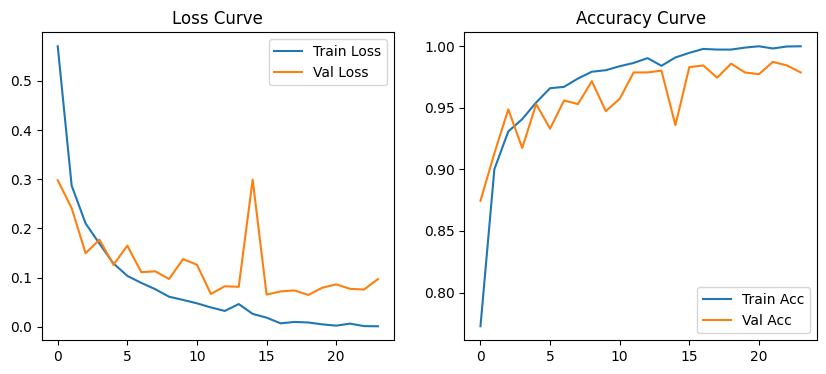


Training completed in 363.60 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9977    1.0000    0.9988      1296
  meningioma     0.9992    0.9985    0.9989      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     1.0000    0.9986    0.9993      1405

    accuracy                         0.9993      5617
   macro avg     0.9992    0.9993    0.9992      5617
weighted avg     0.9993    0.9993    0.9993      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9581    0.9877    0.9726       162
  meningioma     0.9875    0.9634    0.9753       164
     notumor     0.9950    1.0000    0.9975       200
   pituitary     1.0000    0.9886    0.9943       175

    accuracy                         0.9857       701
   macro avg     0.9852    0.9849    0.9849       701
weighted avg     0.9860    0.9857    0.9858       701


=== Test Cl

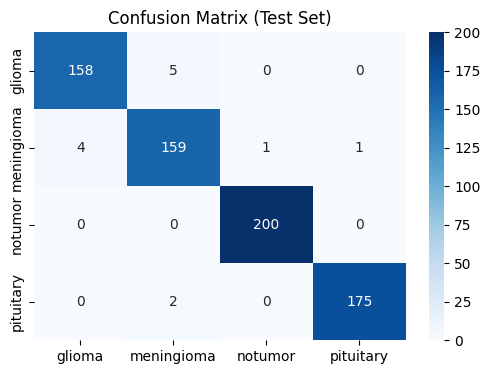


Cohen’s Kappa: 0.9754
Mean PPV: 0.9806
Mean NPV: 0.9940
Mean Sensitivity: 0.9804
Mean Specificity: 0.9939


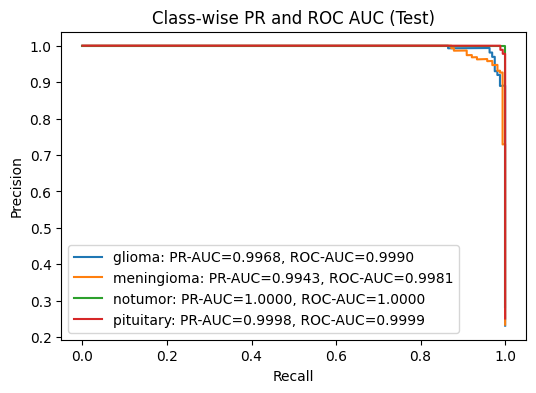


Accuracy: 0.9816
95% Confidence Interval: (0.9716, 0.9901)

GPU Memory Used: 30.71 MB
RAM Used: 2.30 GB
Inference Time: 1.23 seconds
Training Time: 363.60 seconds

Permutation Test p-value (accuracy vs random): 0.0000


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - SqueezeNet + SE
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    roc_auc_score, precision_recall_curve, auc
)
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Squeeze-and-Excitation (SE) Block
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.fc(x)
        return x * scale

# ============================================================
# 3️⃣ SqueezeNet + SE Head
# ============================================================

class SqueezeNet_SE(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.squeezenet1_1(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.se = SEBlock(channels=512)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.se(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = SqueezeNet_SE(num_classes=num_classes).to(device)

# ============================================================
# 4️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 5️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_squeezenet_se.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 6️⃣ Training + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_squeezenet_se.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 7️⃣ Test Evaluation (Detailed + Permutation p-value)
# ============================================================

def evaluate_test(model, loader, training_time):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))

    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

    # ===================== Permutation Test =====================
    n_permutations = 100
    perm_accs = []
    y_true_arr = np.array(y_true)
    for _ in range(n_permutations):
        perm_labels = np.random.permutation(y_true_arr)
        perm_accs.append(np.mean(perm_labels == y_pred))
    perm_accs = np.array(perm_accs)
    p_value = np.mean(perm_accs >= acc)
    print(f"\nPermutation Test p-value (accuracy vs random): {p_value:.4f}")

# ============================================================
# 8️⃣ Evaluate Test Set
# ============================================================

evaluate_test(model, test_loader, training_time)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.3701 | Val Loss: 0.1283 | Train Acc: 0.8752 | Val Acc: 0.9586
Epoch [2/50] | Train Loss: 0.0958 | Val Loss: 0.0630 | Train Acc: 0.9701 | Val Acc: 0.9757
Epoch [3/50] | Train Loss: 0.0389 | Val Loss: 0.0547 | Train Acc: 0.9868 | Val Acc: 0.9843
Epoch [4/50] | Train Loss: 0.0290 | Val Loss: 0.0361 | Train Acc: 0.9916 | Val Acc: 0.9886
Epoch [5/50] | Train Loss: 0.0226 | Val Loss: 0.0328 | Train Acc: 0.9941 | Val Acc: 0.9857
Epoch [6/50] | Train Loss: 0.0158 | Val Loss: 0.0380 | Train Acc: 0.9954 | Val Acc: 0.9872
Epoch [7/50] | Train Loss: 0.0089 | Val Loss: 0.0380 | Train Acc: 0.9975 | Val Acc: 0.9900
Epoch [8/50] | Train Loss: 0.0060 | Val Loss: 0.0384 | Train Acc: 0.9980 | Val Acc: 0.9900
Epoch [9/50] | Train Loss: 0.0033 | Val Loss: 0.0230 | Train Acc: 0.9996 | Val Acc: 0.9929
Epoch [10/50] | Train Loss: 0.0075 | Val Loss: 0.0282 | Train Acc: 0.9977 | Val Acc: 0.9914
Epoch [11/50] | Train Loss: 0.0021 | Val Loss: 0.0269 | Train Acc: 0.9998 | Val Acc: 0.99

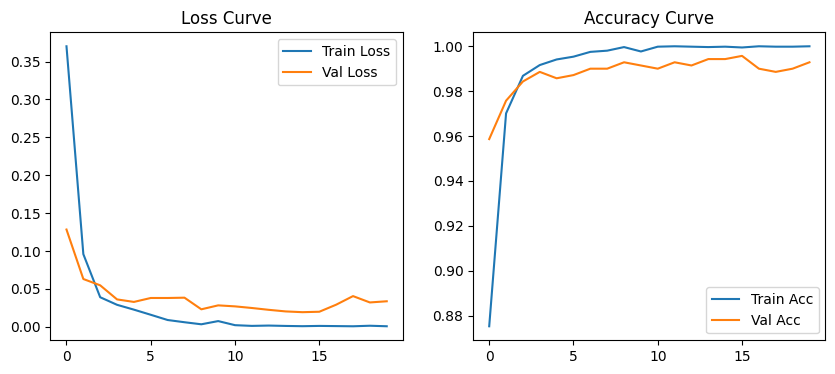


Training completed in 456.68 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      1296
  meningioma     1.0000    1.0000    1.0000      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     1.0000    1.0000    1.0000      1405

    accuracy                         1.0000      5617
   macro avg     1.0000    1.0000    1.0000      5617
weighted avg     1.0000    1.0000    1.0000      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9938    0.9938    0.9938       162
  meningioma     0.9878    0.9878    0.9878       164
     notumor     1.0000    1.0000    1.0000       200
   pituitary     0.9943    0.9943    0.9943       175

    accuracy                         0.9943       701
   macro avg     0.9940    0.9940    0.9940       701
weighted avg     0.9943    0.9943    0.9943       701


=== Test Cl

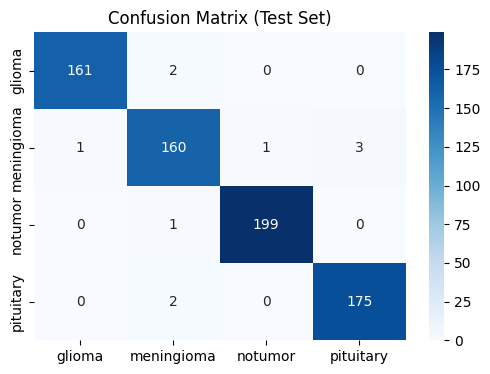


Cohen’s Kappa: 0.9810
Mean PPV: 0.9854
Mean NPV: 0.9953
Mean Sensitivity: 0.9853
Mean Specificity: 0.9953


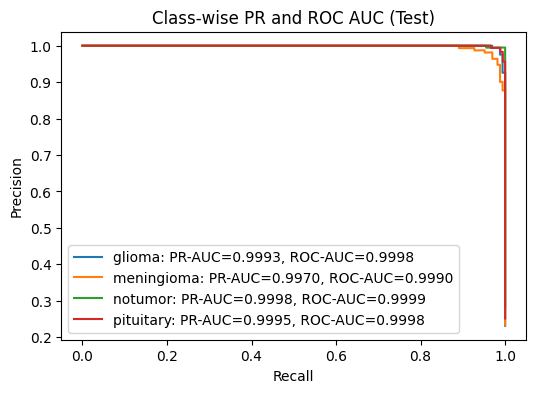


Accuracy: 0.9858
95% Confidence Interval: (0.9759, 0.9943)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 15939.68it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 313.27 MB
RAM Used: 2.68 GB
Inference Time: 1.34 seconds
Training Time: 456.68 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - MobileNetV2 + SE Block
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Squeeze-and-Excitation (SE) Block
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, H, W = x.size()
        w = self.fc(x).view(B, C, 1, 1)
        return x * w

# ============================================================
# 3️⃣ MobileNetV2 + SE Head
# ============================================================

class MobileNetV2_SE(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.se = SEBlock(channels=1280)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.se(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = MobileNetV2_SE(num_classes=num_classes).to(device)

# ============================================================
# 4️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 5️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_mobilenetv2_se.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 6️⃣ Training + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_mobilenetv2_se.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 7️⃣ Test Evaluation (Detailed) + Permutation Accuracy
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    # --- Classification Report ---
    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    # --- Cohen's Kappa ---
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and 95% CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation-based accuracy ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 183MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.2672 | Val Loss: 0.1315 | Train Acc: 0.9202 | Val Acc: 0.9572
Epoch [2/50] | Train Loss: 0.0608 | Val Loss: 0.0645 | Train Acc: 0.9804 | Val Acc: 0.9757
Epoch [3/50] | Train Loss: 0.0281 | Val Loss: 0.0492 | Train Acc: 0.9916 | Val Acc: 0.9886
Epoch [4/50] | Train Loss: 0.0127 | Val Loss: 0.0331 | Train Acc: 0.9966 | Val Acc: 0.9914
Epoch [5/50] | Train Loss: 0.0110 | Val Loss: 0.0208 | Train Acc: 0.9973 | Val Acc: 0.9929
Epoch [6/50] | Train Loss: 0.0026 | Val Loss: 0.0306 | Train Acc: 0.9996 | Val Acc: 0.9914
Epoch [7/50] | Train Loss: 0.0202 | Val Loss: 0.0466 | Train Acc: 0.9936 | Val Acc: 0.9843
Epoch [8/50] | Train Loss: 0.0283 | Val Loss: 0.0664 | Train Acc: 0.9915 | Val Acc: 0.9772
Epoch [9/50] | Train Loss: 0.0122 | Val Loss: 0.0351 | Train Acc: 0.9970 | Val Acc: 0.9886
Epoch [10/50] | Train Loss: 0.0036 | Val Loss: 0.0292 | Train Acc: 0.9993 | Val Acc: 0.9929
Early stopping triggered.


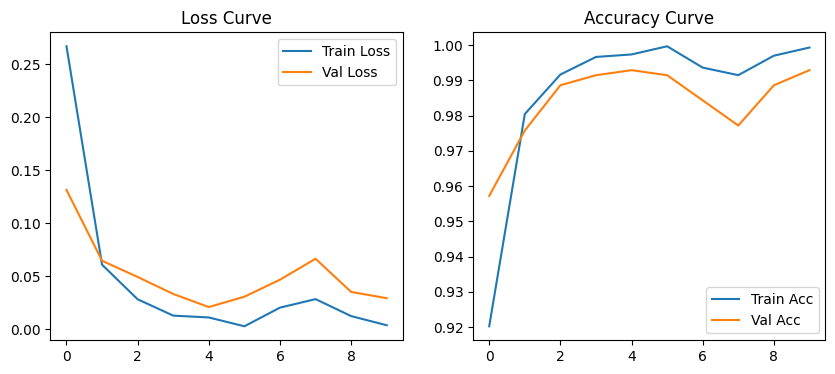


Training completed in 614.89 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      1296
  meningioma     1.0000    0.9992    0.9996      1316
     notumor     0.9994    1.0000    0.9997      1600
   pituitary     1.0000    1.0000    1.0000      1405

    accuracy                         0.9998      5617
   macro avg     0.9998    0.9998    0.9998      5617
weighted avg     0.9998    0.9998    0.9998      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9938    0.9877    0.9907       162
  meningioma     0.9818    0.9878    0.9848       164
     notumor     1.0000    1.0000    1.0000       200
   pituitary     0.9943    0.9943    0.9943       175

    accuracy                         0.9929       701
   macro avg     0.9925    0.9924    0.9925       701
weighted avg     0.9929    0.9929    0.9929       701


=== Test Cl

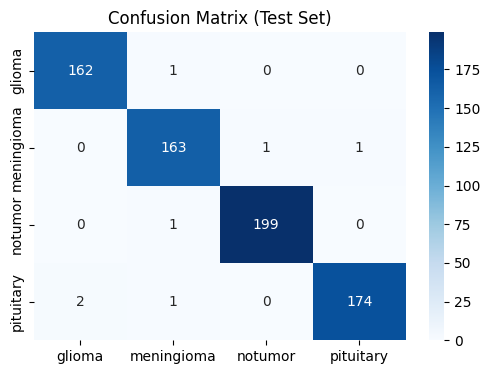


Cohen’s Kappa: 0.9867
Mean PPV: 0.9898
Mean NPV: 0.9967
Mean Sensitivity: 0.9899
Mean Specificity: 0.9967


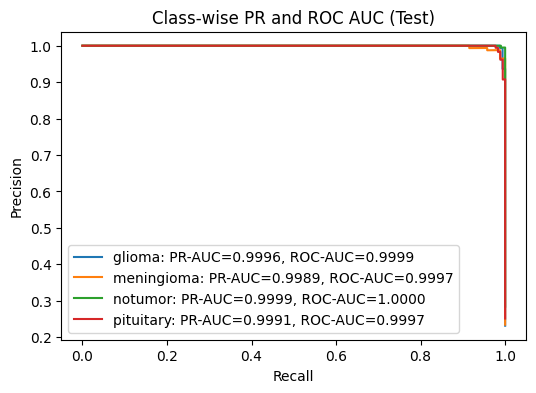


Accuracy: 0.9901
95% Confidence Interval: (0.9816, 0.9972)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 16381.57it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 303.58 MB
RAM Used: 2.42 GB
Inference Time: 3.09 seconds
Training Time: 614.89 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - DenseNet201 + SE Block
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Squeeze-and-Excitation (SE) Block
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, H, W = x.size()
        w = self.fc(x).view(B, C, 1, 1)
        return x * w

# ============================================================
# 3️⃣ DenseNet201 + SE Head
# ============================================================

class DenseNet201_SE(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = models.densenet201(weights='IMAGENET1K_V1')
        self.features = base_model.features
        self.se = SEBlock(channels=1920)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1920, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        x = self.se(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = DenseNet201_SE(num_classes=num_classes).to(device)

# ============================================================
# 4️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 5️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_densenet201_se.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 6️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_densenet201_se.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 7️⃣ Test Evaluation (Detailed) + Permutation Accuracy
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    # --- Classification Report ---
    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    # --- Cohen's Kappa ---
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and 95% CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation-based accuracy ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.4170 | Val Loss: 0.0908 | Train Acc: 0.8823 | Val Acc: 0.9757
Epoch [2/50] | Train Loss: 0.0575 | Val Loss: 0.0363 | Train Acc: 0.9854 | Val Acc: 0.9843
Epoch [3/50] | Train Loss: 0.0234 | Val Loss: 0.0425 | Train Acc: 0.9941 | Val Acc: 0.9872
Epoch [4/50] | Train Loss: 0.0237 | Val Loss: 0.0368 | Train Acc: 0.9931 | Val Acc: 0.9872
Epoch [5/50] | Train Loss: 0.0123 | Val Loss: 0.0278 | Train Acc: 0.9964 | Val Acc: 0.9914
Epoch [6/50] | Train Loss: 0.0097 | Val Loss: 0.0317 | Train Acc: 0.9972 | Val Acc: 0.9900
Epoch [7/50] | Train Loss: 0.0095 | Val Loss: 0.0861 | Train Acc: 0.9975 | Val Acc: 0.9700
Epoch [8/50] | Train Loss: 0.0035 | Val Loss: 0.0101 | Train Acc: 0.9993 | Val Acc: 0.9957
Epoch [9/50] | Train Loss: 0.0026 | Val Loss: 0.0186 | Train Acc: 0.9993 | Val Acc: 0.9943
Epoch [10/50] | Train Loss: 0.0031 | Val Loss: 0.0378 | Train Acc: 0.9995 | Val Acc: 0.9900
Epoch [11/50] | Train Loss: 0.0028 | Val Loss: 0.0548 | Train Acc: 0.9993 | Val Acc: 0.98

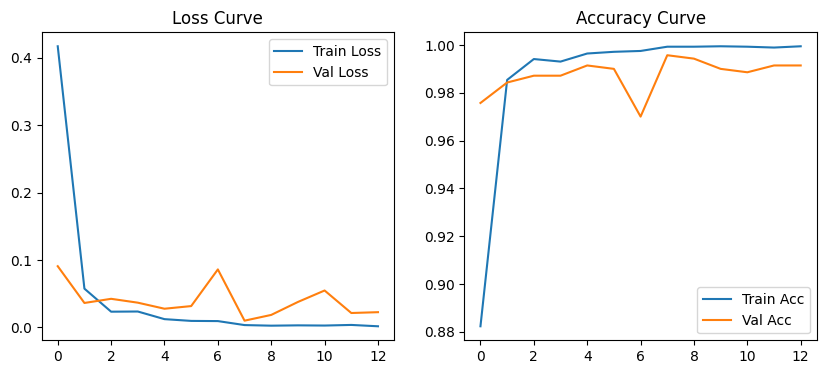


Training completed in 798.74 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    1.0000    1.0000      1296
  meningioma     1.0000    1.0000    1.0000      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     1.0000    1.0000    1.0000      1405

    accuracy                         1.0000      5617
   macro avg     1.0000    1.0000    1.0000      5617
weighted avg     1.0000    1.0000    1.0000      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     1.0000    0.9877    0.9938       162
  meningioma     0.9939    0.9939    0.9939       164
     notumor     1.0000    1.0000    1.0000       200
   pituitary     0.9887    1.0000    0.9943       175

    accuracy                         0.9957       701
   macro avg     0.9957    0.9954    0.9955       701
weighted avg     0.9958    0.9957    0.9957       701


=== Test Cl

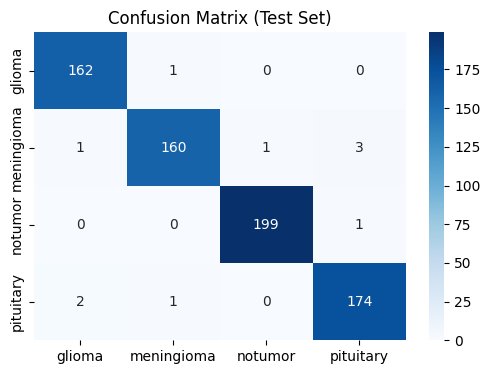


Cohen’s Kappa: 0.9810
Mean PPV: 0.9855
Mean NPV: 0.9953
Mean Sensitivity: 0.9854
Mean Specificity: 0.9953


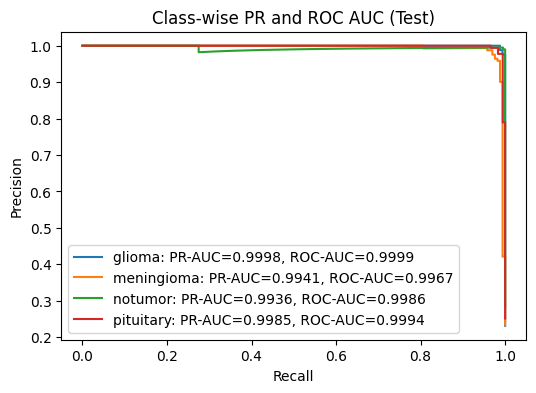


Accuracy: 0.9858
95% Confidence Interval: (0.9759, 0.9943)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 16588.51it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 528.71 MB
RAM Used: 2.66 GB
Inference Time: 2.63 seconds
Training Time: 798.74 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - Xception + SE Block
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from scipy import stats

# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir   = "/kaggle/working/brain_split/val"
test_dir  = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds   = datasets.ImageFolder(val_dir, transform=transform)
test_ds  = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ SE Block
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, H, W = x.size()
        w = self.fc(x).view(B, C, 1, 1)
        return x * w

# ============================================================
# 3️⃣ Xception + SE Head
# ============================================================

class Xception_SE(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        base_model = timm.create_model('xception', pretrained=True, features_only=True)
        self.features = base_model
        self.se = SEBlock(channels=2048)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)[-1]
        x = self.se(x)
        x = x.mean(dim=[2,3])
        x = self.fc(x)
        return x

model = Xception_SE(num_classes=num_classes).to(device)

# ============================================================
# 4️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 5️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        # Validation
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val
        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_xception_se.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 6️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_xception_se.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 7️⃣ Test Evaluation (Detailed) + Permutation Accuracy
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    # --- Classification Report ---
    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    # --- Cohen's Kappa ---
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and 95% CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation-based accuracy ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 218MB/s] 
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] | Train Loss: 0.2512 | Val Loss: 0.1085 | Train Acc: 0.9206 | Val Acc: 0.9572
Epoch [2/50] | Train Loss: 0.0472 | Val Loss: 0.1069 | Train Acc: 0.9852 | Val Acc: 0.9643
Epoch [3/50] | Train Loss: 0.0465 | Val Loss: 0.0604 | Train Acc: 0.9859 | Val Acc: 0.9772
Epoch [4/50] | Train Loss: 0.0227 | Val Loss: 0.0917 | Train Acc: 0.9920 | Val Acc: 0.9700
Epoch [5/50] | Train Loss: 0.0247 | Val Loss: 0.0653 | Train Acc: 0.9927 | Val Acc: 0.9815
Epoch [6/50] | Train Loss: 0.0277 | Val Loss: 0.0496 | Train Acc: 0.9920 | Val Acc: 0.9843
Epoch [7/50] | Train Loss: 0.0324 | Val Loss: 0.0484 | Train Acc: 0.9902 | Val Acc: 0.9872
Epoch [8/50] | Train Loss: 0.0092 | Val Loss: 0.0393 | Train Acc: 0.9979 | Val Acc: 0.9857
Epoch [9/50] | Train Loss: 0.0157 | Val Loss: 0.0362 | Train Acc: 0.9952 | Val Acc: 0.9872
Epoch [10/50] | Train Loss: 0.0168 | Val Loss: 0.0271 | Train Acc: 0.9947 | Val Acc: 0.9886
Epoch [11/50] | Train Loss: 0.0264 | Val Loss: 0.0638 | Train Acc: 0.9920 | Val Acc: 0.98

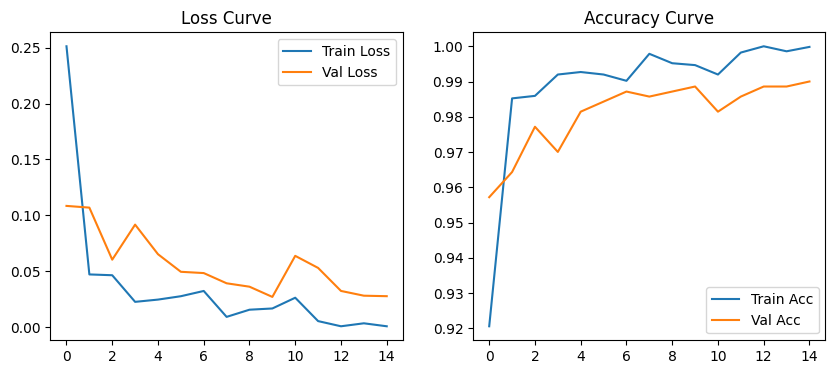


Training completed in 872.70 seconds.

=== Train Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9977    1.0000    0.9988      1296
  meningioma     0.9992    0.9992    0.9992      1316
     notumor     1.0000    1.0000    1.0000      1600
   pituitary     1.0000    0.9979    0.9989      1405

    accuracy                         0.9993      5617
   macro avg     0.9992    0.9993    0.9993      5617
weighted avg     0.9993    0.9993    0.9993      5617


=== Validation Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9641    0.9938    0.9787       162
  meningioma     0.9876    0.9695    0.9785       164
     notumor     1.0000    1.0000    1.0000       200
   pituitary     1.0000    0.9886    0.9943       175

    accuracy                         0.9886       701
   macro avg     0.9879    0.9880    0.9879       701
weighted avg     0.9888    0.9886    0.9886       701


=== Test Cl

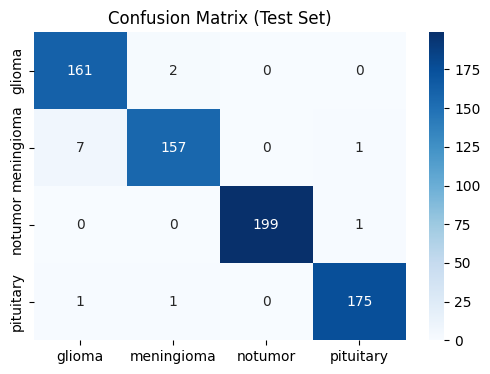


Cohen’s Kappa: 0.9754
Mean PPV: 0.9807
Mean NPV: 0.9940
Mean Sensitivity: 0.9807
Mean Specificity: 0.9940


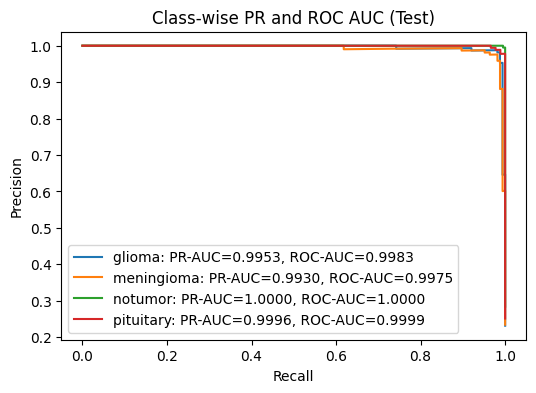


Accuracy: 0.9816
95% Confidence Interval: (0.9716, 0.9901)


Permutation test: 100%|██████████| 1000/1000 [00:00<00:00, 16132.99it/s]

Permutation-based accuracy p-value: 0.0000

GPU Memory Used: 696.69 MB
RAM Used: 2.64 GB
Inference Time: 2.74 seconds
Training Time: 872.70 seconds


In [ ]:
# ============================================================
# 🧠 Brain MRI Tumor Classification - ResNet101 + SE
# ============================================================

import os, time, psutil, torch, numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from tqdm import tqdm


# ============================================================
# 1️⃣ Setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 32
train_dir = "/kaggle/working/brain_split/train"
val_dir = "/kaggle/working/brain_split/val"
test_dir = "/kaggle/working/brain_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# 2️⃣ Squeeze-and-Excitation (SE) Block
# ============================================================

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, H, W = x.size()
        y = self.avg_pool(x).view(B, C)
        y = self.fc(y).view(B, C, 1, 1)
        return x * y.expand_as(x)

# ============================================================
# 3️⃣ ResNet101 + SE Head
# ============================================================

class ResNet101_SE(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()

        base_model = models.resnet101(weights='IMAGENET1K_V1')
        self.features = nn.Sequential(*list(base_model.children())
        self.se = SEBlock(channels=2048)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.se(x)
        x = self.fc(x)
        return x

model = ResNet101_SE(num_classes=num_classes).to(device)

# ============================================================
# 4️⃣ Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

# ============================================================
# 5️⃣ Training Loop
# ============================================================

def evaluate_simple(model, loader, name="Set"):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def train_model(model):
    global best_val_loss, patience_counter
    start_time = time.time()
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_train = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / total_train
        train_accuracy = train_correct / total_train

        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / total_val
        val_accuracy = val_correct / total_val

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_resnet101_se.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    end_time = time.time()
    training_time = end_time - start_time

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend(); plt.title("Loss Curve")
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend(); plt.title("Accuracy Curve")
    plt.show()

    print(f"\nTraining completed in {training_time:.2f} seconds.")
    return training_time

# ============================================================
# 6️⃣ Train + Validation Reports
# ============================================================

training_time = train_model(model)
model.load_state_dict(torch.load("best_resnet101_se.pth"))

evaluate_simple(model, train_loader, "Train")
evaluate_simple(model, val_loader, "Validation")

# ============================================================
# 7️⃣ Test Evaluation (Detailed) + Permutation Accuracy
# ============================================================

def evaluate_test(model, loader, n_permutations=1000):
    y_true, y_pred, y_prob = [], [], []
    start_inf = time.time()

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    end_inf = time.time()
    inference_time = end_inf - start_inf

    # --- Classification Report ---
    print("\n=== Test Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    # --- Cohen's Kappa ---
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"\nCohen’s Kappa: {kappa:.4f}")

    # --- Mean PPV, NPV, Sensitivity, Specificity ---
    metrics = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)
        ppv = tp / (tp + fp + 1e-8)
        npv = tn / (tn + fn + 1e-8)
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        metrics.append((ppv, npv, sens, spec))
    metrics = np.array(metrics)
    mean_ppv, mean_npv, mean_sens, mean_spec = metrics.mean(axis=0)
    print(f"Mean PPV: {mean_ppv:.4f}")
    print(f"Mean NPV: {mean_npv:.4f}")
    print(f"Mean Sensitivity: {mean_sens:.4f}")
    print(f"Mean Specificity: {mean_spec:.4f}")

    # --- ROC & PR Curves ---
    y_true_bin = np.eye(num_classes)[y_true]
    plt.figure(figsize=(6, 4))
    for i, c in enumerate(class_names):
        roc_auc = roc_auc_score(y_true_bin[:, i], np.array(y_prob)[:, i])
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], np.array(y_prob)[:, i])
        pr_auc = auc(rec, prec)
        plt.plot(rec, prec, label=f'{c}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}')
    plt.title("Class-wise PR and ROC AUC (Test)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # --- Accuracy and 95% CI ---
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    ci_low, ci_high = stats.binom.interval(0.95, len(y_true), acc)
    ci_low /= len(y_true)
    ci_high /= len(y_true)
    print(f"\nAccuracy: {acc:.4f}")
    print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")

    # --- Permutation-based accuracy ---
    perm_acc = []
    y_true_arr = np.array(y_true)
    for _ in tqdm(range(n_permutations), desc="Permutation test"):
        y_perm = np.random.permutation(y_true_arr)
        perm_acc.append(np.mean(y_perm == np.array(y_pred)))
    perm_acc = np.array(perm_acc)
    p_value = np.mean(perm_acc >= acc)
    print(f"Permutation-based accuracy p-value: {p_value:.4f}")

    # --- Resource Usage ---
    try:
        gpu_mem = torch.cuda.memory_allocated() / (1024 ** 2)
    except:
        gpu_mem = 0
    ram_usage = psutil.virtual_memory().used / (1024**3)
    print(f"\nGPU Memory Used: {gpu_mem:.2f} MB")
    print(f"RAM Used: {ram_usage:.2f} GB")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Training Time: {training_time:.2f} seconds")

# ============================================================
# Run Test Evaluation
# ============================================================

evaluate_test(model, test_loader, n_permutations=1000)
